In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn --quiet


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,828 (679.02 KB)

 Trainable params: 173,444 (677.52 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/2
403/403 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6500 - loss: 0.9494 - val_accuracy: 0.7886 - val_loss: 0.5190
Epoch 2/2
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7832 - loss: 0.5090 - val_accuracy: 0.8241 - val_loss: 0.4068
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8296 - loss: 0.3993
✅ Test Accuracy: 82.19%
✅ Functional clone ready with identical weights.


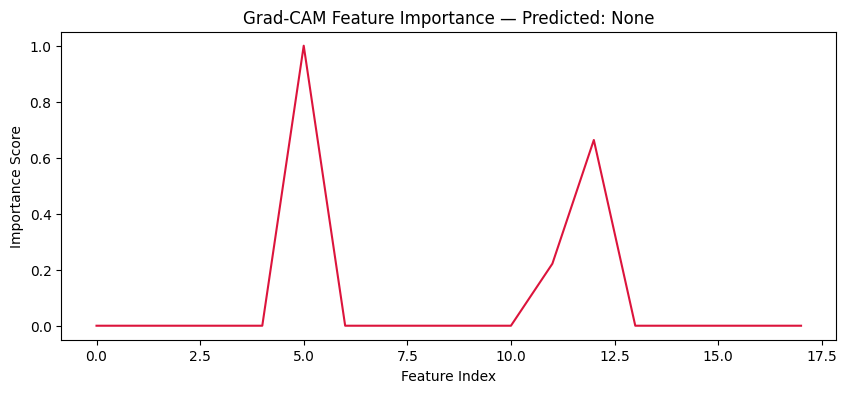

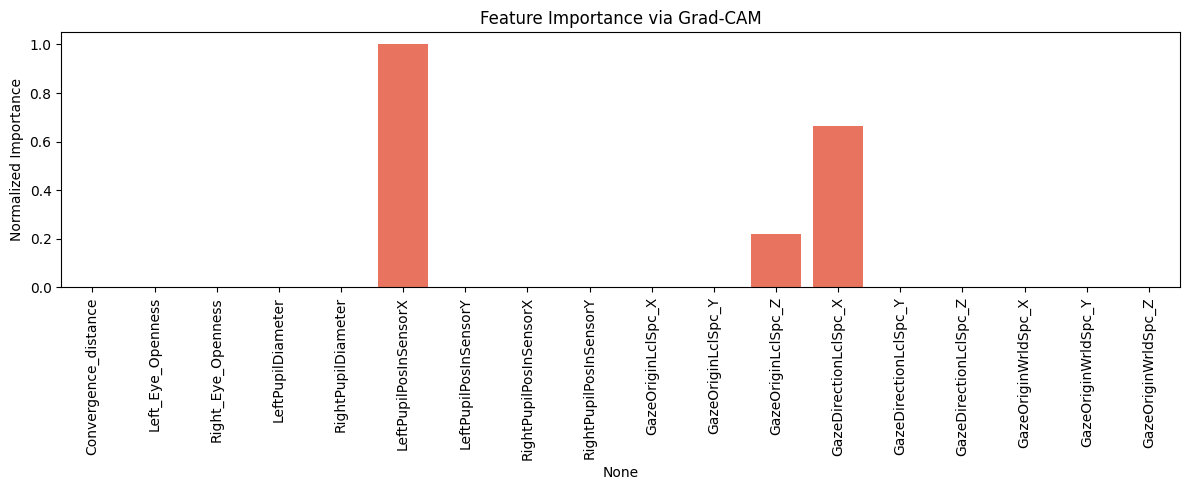

In [7]:


import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1️⃣ Load and preprocess dataset
# -----------------------------
df = pd.read_csv("/content/sample_data/All_CS_rifat_data.csv")
# Map fms values to cybersickness levels
def map_fms(fms):
    if fms == 0:
        return "None"
    elif fms == 1:
        return "Low"
    elif fms in [2, 3]:
        return "Medium"
    else:
        return "High"

df['cybersickness_label'] = df['fms'].apply(map_fms)
df = df.drop(columns=['fms'])

# Split features and target
X = df.drop(columns=['cybersickness_label']).values
y = df['cybersickness_label']

# Normalize input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.expand_dims(X_scaled, axis=-1)  # (samples, features, 1)

# Encode target
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# -----------------------------
# 2️⃣ CNN Model
# -----------------------------
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1), name="conv1"),
    BatchNormalization(),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu', name="conv2"),
    BatchNormalization(),
    MaxPooling1D(2),
    Flatten(name="flatten"),
    Dense(128, activation='relu', name="dense1"),
    Dropout(0.3),
    Dense(4, activation='softmax', name="output")
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------------
# 3️⃣ Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# =====================================================
# ✅ GUARANTEED WORKING GRAD-CAM (Functional Clone)
# =====================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1 : rebuild the model functionally and copy weights
inputs = tf.keras.Input(shape=(X_train.shape[1], 1))
x = Conv1D(64, 3, activation='relu', name="conv1")(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Conv1D(128, 3, activation='relu', name="conv2")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu', name="dense1")(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax', name="output")(x)

functional_model = Model(inputs=inputs, outputs=outputs)
functional_model.set_weights(model.get_weights())  # copy trained weights
print("✅ Functional clone ready with identical weights.")

# --- Step 2 : split into convolutional and classifier parts
last_conv_layer = functional_model.get_layer("conv2")
conv_model = Model(inputs=functional_model.input,
                   outputs=last_conv_layer.output)

# build classifier for layers after conv2
x = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
y = x
for lyr in functional_model.layers[functional_model.layers.index(last_conv_layer)+1:]:
    y = lyr(y)
classifier_model = Model(x, y)

# --- Step 3 : select one sample to explain
sample = X_test[0:1]
with tf.GradientTape() as tape:
    conv_output = conv_model(sample)
    tape.watch(conv_output)
    preds = classifier_model(conv_output)
    pred_class = tf.argmax(preds[0])
    loss = preds[:, pred_class]

# --- Step 4 : compute gradients and Grad-CAM heatmap
grads = tape.gradient(loss, conv_output)[0]
pooled_grads = tf.reduce_mean(grads, axis=0)
conv_output = conv_output[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1).numpy()
heatmap = np.maximum(heatmap, 0)
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-10)

# --- Step 5 : visualize feature importance
feature_names = df.drop(columns=['cybersickness_label']).columns

plt.figure(figsize=(10,4))
plt.title(f"Grad-CAM Feature Importance — Predicted: {encoder.classes_[pred_class]}")
plt.plot(heatmap, color='crimson')
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=feature_names[:len(heatmap)], y=heatmap, color='tomato')
plt.xticks(rotation=90)
plt.title("Feature Importance via Grad-CAM")
plt.ylabel("Normalized Importance")
plt.tight_layout()
plt.show()



Computing Grad-CAM for test samples: 100%|██████████| 4021/4021 [01:51<00:00, 36.06it/s]


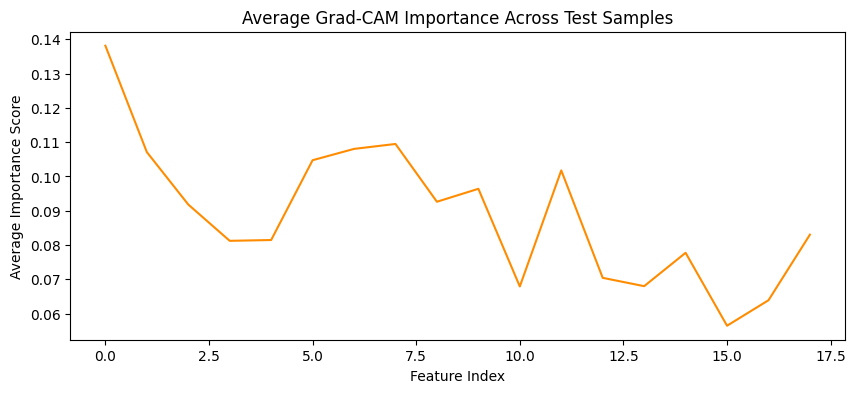

/tmp/ipython-input-536468867.py:47: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


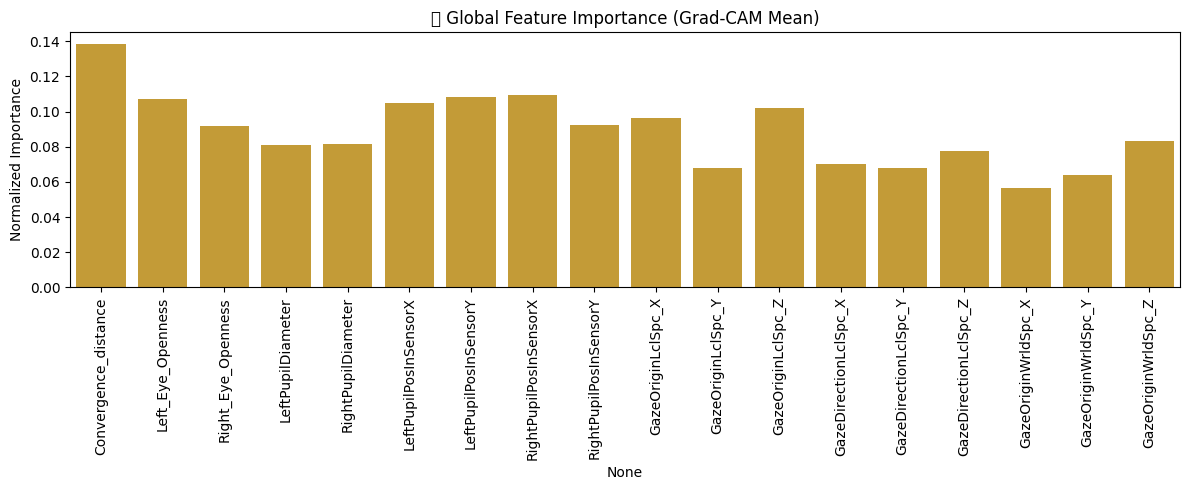


🔝 Top 10 Most Influential Features for Cybersickness Prediction:
• Convergence_distance                → importance = 0.1381
• RightPupilPosInSensorX              → importance = 0.1095
• LeftPupilPosInSensorY               → importance = 0.1080
• Left_Eye_Openness                   → importance = 0.1071
• LeftPupilPosInSensorX               → importance = 0.1047
• GazeOriginLclSpc_Z                  → importance = 0.1018
• GazeOriginLclSpc_X                  → importance = 0.0964
• RightPupilPosInSensorY              → importance = 0.0926
• Right_Eye_Openness                  → importance = 0.0918
• GazeOriginWrldSpc_Z                 → importance = 0.0830


In [8]:
# =====================================================
# 🌎 GLOBAL GRAD-CAM FEATURE IMPORTANCE
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Step 1 : Compute Grad-CAM for each sample in test set
all_heatmaps = []
num_samples = len(X_test)

for i in tqdm(range(num_samples), desc="Computing Grad-CAM for test samples"):
    sample = X_test[i:i+1]
    with tf.GradientTape() as tape:
        conv_output = conv_model(sample)
        tape.watch(conv_output)
        preds = classifier_model(conv_output)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]
    grads = tape.gradient(loss, conv_output)[0]
    pooled_grads = tf.reduce_mean(grads, axis=0)
    conv_output_ = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output_), axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-10)
    all_heatmaps.append(heatmap)

# --- Step 2 : Average Grad-CAM across all samples
avg_heatmap = np.mean(all_heatmaps, axis=0)

# --- Step 3 : Visualization
feature_names = df.drop(columns=['cybersickness_label']).columns

plt.figure(figsize=(10,4))
plt.plot(avg_heatmap, color='darkorange')
plt.title("Average Grad-CAM Importance Across Test Samples")
plt.xlabel("Feature Index")
plt.ylabel("Average Importance Score")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=feature_names[:len(avg_heatmap)], y=avg_heatmap, color='goldenrod')
plt.xticks(rotation=90)
plt.title("🌎 Global Feature Importance (Grad-CAM Mean)")
plt.ylabel("Normalized Importance")
plt.tight_layout()
plt.show()

# --- Step 4 : Identify top influential features
top_indices = np.argsort(avg_heatmap)[::-1][:10]
top_features = [(feature_names[i], avg_heatmap[i]) for i in top_indices]
print("\n🔝 Top 10 Most Influential Features for Cybersickness Prediction:")
for f, v in top_features:
    print(f"• {f:35s} → importance = {v:.4f}")

Computing Grad-CAM for test samples: 100%|██████████| 4021/4021 [01:52<00:00, 35.78it/s]


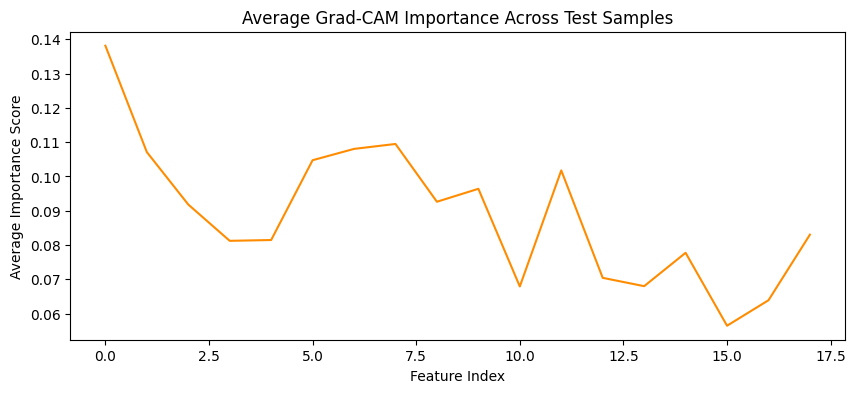

/tmp/ipython-input-760072414.py:49: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


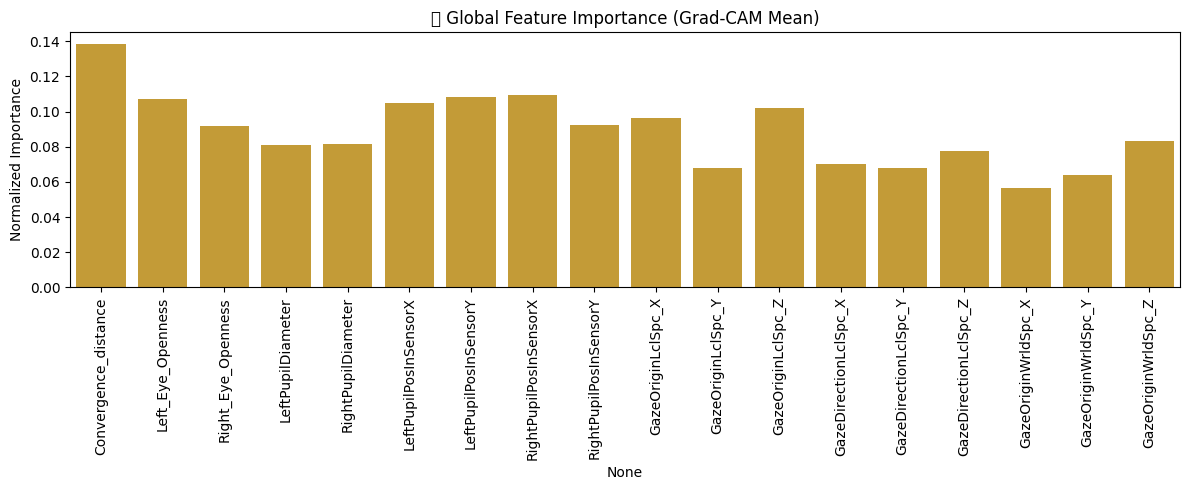

/tmp/ipython-input-760072414.py:60: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


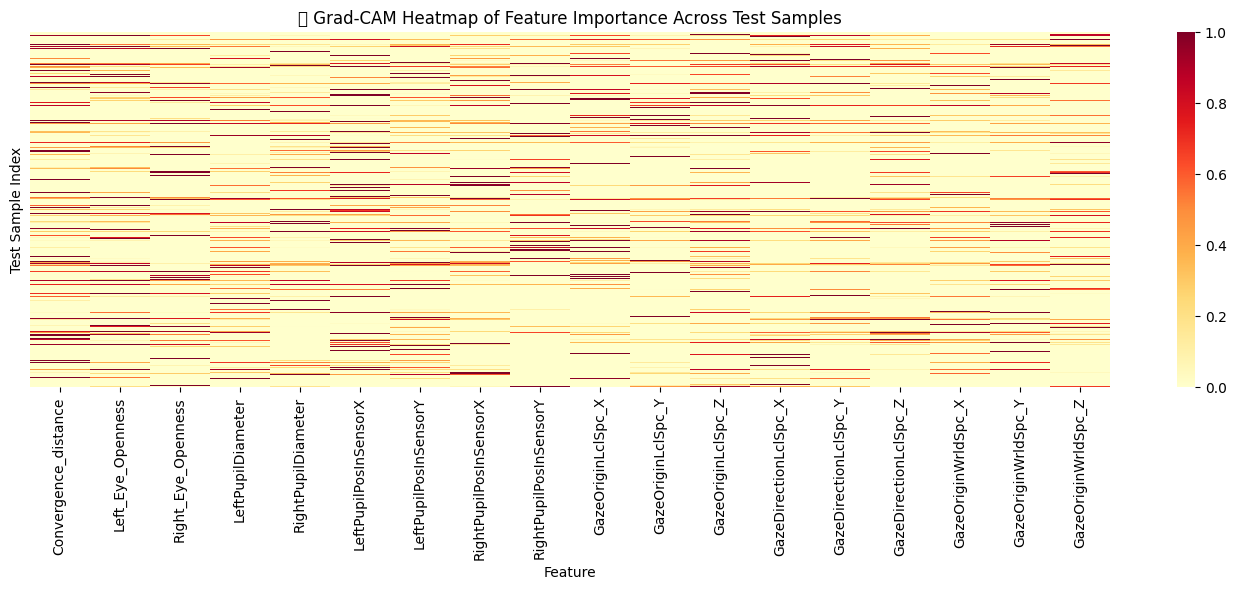


🔝 Top 10 Most Influential Features for Cybersickness Prediction:
• Convergence_distance                → importance = 0.1381
• RightPupilPosInSensorX              → importance = 0.1095
• LeftPupilPosInSensorY               → importance = 0.1080
• Left_Eye_Openness                   → importance = 0.1071
• LeftPupilPosInSensorX               → importance = 0.1047
• GazeOriginLclSpc_Z                  → importance = 0.1018
• GazeOriginLclSpc_X                  → importance = 0.0964
• RightPupilPosInSensorY              → importance = 0.0926
• Right_Eye_Openness                  → importance = 0.0918
• GazeOriginWrldSpc_Z                 → importance = 0.0830


In [9]:
# =====================================================
# 🌎 GLOBAL GRAD-CAM FEATURE IMPORTANCE + HEATMAP
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Step 1 : Compute Grad-CAM for every test sample
all_heatmaps = []
num_samples = len(X_test)

for i in tqdm(range(num_samples), desc="Computing Grad-CAM for test samples"):
    sample = X_test[i:i+1]
    with tf.GradientTape() as tape:
        conv_output = conv_model(sample)
        tape.watch(conv_output)
        preds = classifier_model(conv_output)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]
    grads = tape.gradient(loss, conv_output)[0]
    pooled_grads = tf.reduce_mean(grads, axis=0)
    conv_output_ = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output_), axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-10)
    all_heatmaps.append(heatmap)

all_heatmaps = np.array(all_heatmaps)

# --- Step 2 : Average Grad-CAM across samples
avg_heatmap = np.mean(all_heatmaps, axis=0)

# --- Step 3 : Visualization — global importance
feature_names = df.drop(columns=['cybersickness_label']).columns

plt.figure(figsize=(10,4))
plt.plot(avg_heatmap, color='darkorange')
plt.title("Average Grad-CAM Importance Across Test Samples")
plt.xlabel("Feature Index")
plt.ylabel("Average Importance Score")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=feature_names[:len(avg_heatmap)], y=avg_heatmap, color='goldenrod')
plt.xticks(rotation=90)
plt.title("🌎 Global Feature Importance (Grad-CAM Mean)")
plt.ylabel("Normalized Importance")
plt.tight_layout()
plt.show()

# --- Step 4 : Heatmap across all test samples
plt.figure(figsize=(14,6))
sns.heatmap(all_heatmaps, cmap="YlOrRd", cbar=True,
            xticklabels=feature_names[:len(avg_heatmap)],
            yticklabels=False)
plt.title("🔥 Grad-CAM Heatmap of Feature Importance Across Test Samples")
plt.xlabel("Feature")
plt.ylabel("Test Sample Index")
plt.tight_layout()
plt.show()

# --- Step 5 : Top influential features summary
top_indices = np.argsort(avg_heatmap)[::-1][:10]
top_features = [(feature_names[i], avg_heatmap[i]) for i in top_indices]
print("\n🔝 Top 10 Most Influential Features for Cybersickness Prediction:")
for f, v in top_features:
    print(f"• {f:35s} → importance = {v:.4f}")


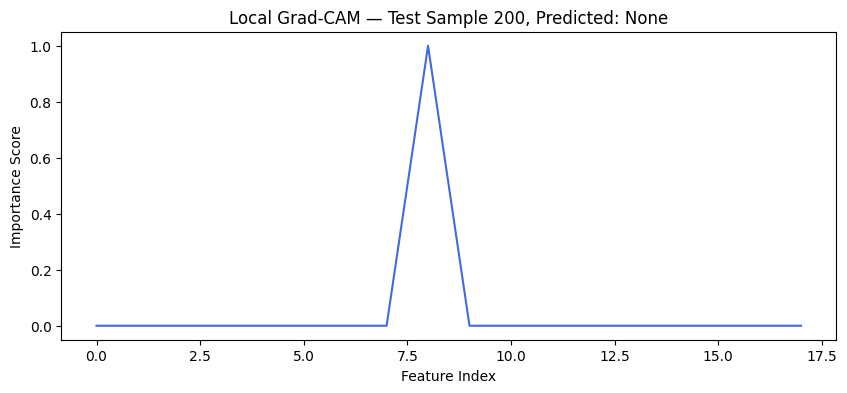

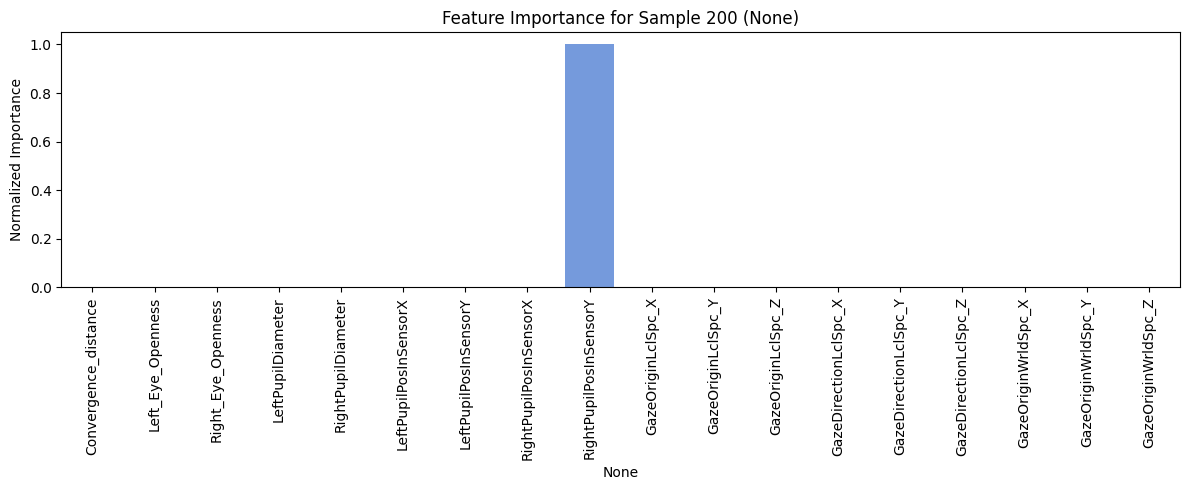

/tmp/ipython-input-324995108.py:56: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-324995108.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


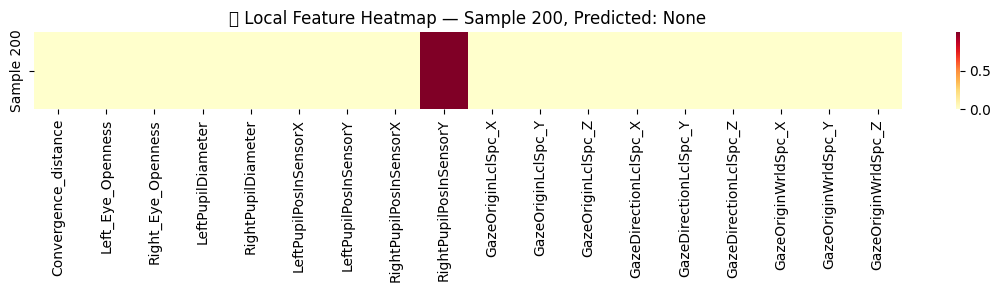


🔍 Top Features Driving Prediction for Sample 200 (None):
• RightPupilPosInSensorY              → importance = 1.0000
• GazeOriginWrldSpc_Z                 → importance = 0.0000
• GazeOriginWrldSpc_Y                 → importance = 0.0000
• GazeOriginWrldSpc_X                 → importance = 0.0000
• GazeDirectionLclSpc_Y               → importance = 0.0000
• GazeDirectionLclSpc_Z               → importance = 0.0000
• GazeDirectionLclSpc_X               → importance = 0.0000
• GazeOriginLclSpc_Z                  → importance = 0.0000


In [11]:
# =====================================================
# 🎯 LOCAL (PER-SAMPLE) GRAD-CAM FEATURE IMPORTANCE
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to compute Grad-CAM for one test sample
def compute_local_gradcam(sample_index):
    sample = X_test[sample_index:sample_index+1]
    with tf.GradientTape() as tape:
        conv_output = conv_model(sample)
        tape.watch(conv_output)
        preds = classifier_model(conv_output)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    grads = tape.gradient(loss, conv_output)[0]
    pooled_grads = tf.reduce_mean(grads, axis=0)
    conv_output_ = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output_), axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-10)

    pred_label = encoder.classes_[pred_class]
    return heatmap, pred_label

# Choose which sample to explain
sample_index = 200  # 👈 change this index (0–len(X_test)-1)
heatmap, pred_label = compute_local_gradcam(sample_index)

# Visualization
feature_names = df.drop(columns=['cybersickness_label']).columns

plt.figure(figsize=(10,4))
plt.plot(heatmap, color='royalblue')
plt.title(f"Local Grad-CAM — Test Sample {sample_index}, Predicted: {pred_label}")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=feature_names[:len(heatmap)], y=heatmap, color='cornflowerblue')
plt.xticks(rotation=90)
plt.title(f"Feature Importance for Sample {sample_index} ({pred_label})")
plt.ylabel("Normalized Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,1))
sns.heatmap(heatmap[np.newaxis, :], cmap="YlOrRd", cbar=True,
            xticklabels=feature_names[:len(heatmap)], yticklabels=[f"Sample {sample_index}"])
plt.title(f"🔥 Local Feature Heatmap — Sample {sample_index}, Predicted: {pred_label}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print top influential features
top_idx = np.argsort(heatmap)[::-1][:8]
print(f"\n🔍 Top Features Driving Prediction for Sample {sample_index} ({pred_label}):")
for i in top_idx:
    print(f"• {feature_names[i]:35s} → importance = {heatmap[i]:.4f}")
